In [145]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib
#%pip install tensorflow scikit-learn 

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib

In [147]:
df = pd.read_csv('../../dataset_dl.csv')

#df.drop(columns=['Date'], inplace=True)  # Eliminar columna de fecha
df.head()

,media_movil_6m,lag_3,vix,oro_return,eurusd,lag_12,lag_6,volatilidad_3m,inflacion_usa,sp500_return,tipos_fed,curva10Y2Y,activo_return,target
0,0.323551,-0.083591,18.309999,0.047631,1.259002,-0.075485,0.061837,0.095904,0.020352,0.050766,0.98,2.43,0.021999,0.055685
1,0.327246,0.104730,16.629999,-0.032475,1.245206,0.002095,0.105983,0.074301,0.020263,0.017276,1.00,2.32,0.055685,0.060284
2,0.330517,-0.086500,14.550000,0.022960,1.253007,0.045264,0.072579,0.020904,0.016885,0.012209,1.01,2.33,0.060284,0.130434
3,0.346297,0.021999,16.740000,0.038561,1.231300,-0.057962,-0.083591,0.041892,0.017401,-0.016359,1.00,2.26,0.130434,-0.046598
4,0.353514,0.055685,17.190001,-0.094313,1.198294,0.005660,0.104730,0.089149,0.022926,-0.016791,1.00,2.22,-0.046598,0.088440


In [148]:
# Función para generar las particiones preservando las características
# de la serie de tiempo

def division_conjuntos(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    # Definir número de datos en cada subserie
    N = dataframe.shape[0]
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = N - Ntrain - Nval # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain]
    val = dataframe[Ntrain:Ntrain+Nval]
    test = dataframe[Ntrain+Nval:]

    return train, val, test

# Prueba de la función
tr, vl, ts = division_conjuntos(df)

print(f'Tamaño set de entrenamiento: {tr.shape}')
print(f'Tamaño set de validación: {vl.shape}')
print(f'Tamaño set de prueba: {ts.shape}')

Tamaño set de entrenamiento: (212, 14)
Tamaño set de validación: (26, 14)
Tamaño set de prueba: (27, 14)


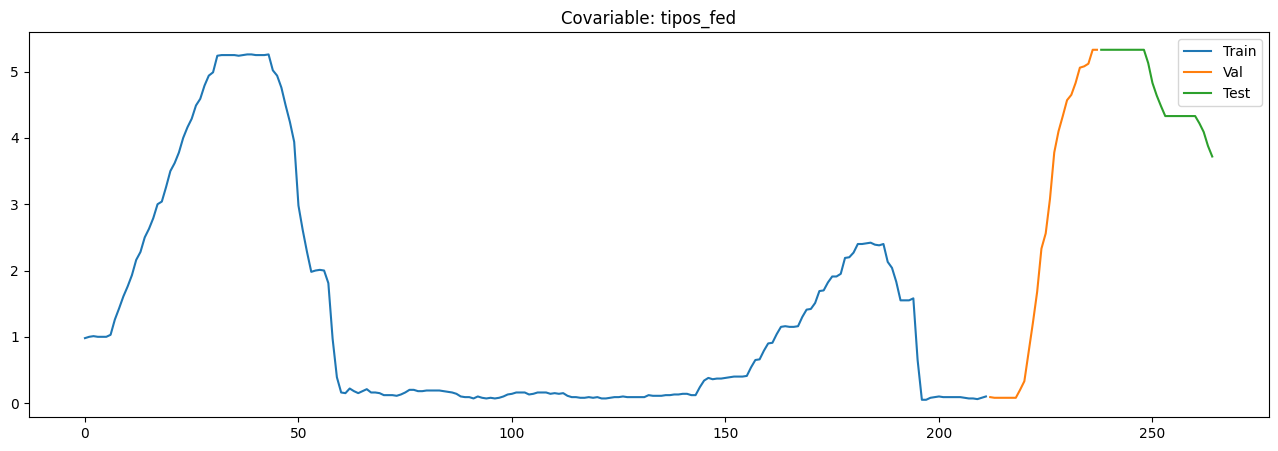

In [149]:
col = df.columns[-4]

# Dibujar los sets de entrenamiento/validación/prueba para la covariable
fig, ax = plt.subplots(figsize = (16,5))
ax.plot(tr[col], label='Train')
ax.plot(vl[col], label='Val')
ax.plot(ts[col], label='Test')
ax.set_title(f'Covariable: {col}')
plt.legend();

In [150]:
INPUT_LENGTH = 6      # Ventana de 6 meses (corto plazo)
OUTPUT_LENGTH = 6     # Predecir 6 meses (corto plazo)
N_UNITS = 32           # Número de neuronas en la capa LSTM
DROPOUT_RATE = 0.2     # Dropout para regularización
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 100

In [151]:
# ============================================
# 3. CREACIÓN DE SECUENCIAS TEMPORALES
# ============================================

def crear_secuencias(dataframe, input_length, output_length):
    """
    Crea secuencias supervisadas para LSTM.
    
    Parámetros:
    - dataframe: DataFrame con los datos (todas las columnas)
    - input_length: número de meses de entrada
    - output_length: número de meses a predecir
    
    Retorna:
    - X: array de entrada (muestras, input_length, features)
    - Y: array de salida (muestras, output_length, 1)
    """
    X, Y = [], []
    features = dataframe.shape[1]
    values = dataframe.values
    
    for i in range(len(values) - input_length - output_length):
        X.append(values[i:i+input_length, :])                    # todas las features
        Y.append(values[i+input_length:i+input_length+output_length, -1])  # target (última columna)
    
    X = np.array(X)
    Y = np.array(Y).reshape(-1, output_length, 1)
    
    return X, Y

# Crear secuencias
X_tr, Y_tr = crear_secuencias(tr, INPUT_LENGTH, OUTPUT_LENGTH)
X_vl, Y_vl = crear_secuencias(vl, INPUT_LENGTH, OUTPUT_LENGTH)
X_ts, Y_ts = crear_secuencias(ts, INPUT_LENGTH, OUTPUT_LENGTH)

print(f'X_tr shape: {X_tr.shape}')  # (muestras, INPUT_LENGTH, features)
print(f'Y_tr shape: {Y_tr.shape}')  # (muestras, OUTPUT_LENGTH, 1)



X_tr shape: (200, 6, 14)
Y_tr shape: (200, 6, 1)


In [152]:
# ============================================
# 4. ESCALADO DE LOS DATOS
# ============================================

# Escalar X (todas las características)
scaler_X = MinMaxScaler(feature_range=(-1, 1))

# Reorganizar para escalar (necesitamos 2D para fit)
X_tr_reshaped = X_tr.reshape(-1, X_tr.shape[-1])
X_vl_reshaped = X_vl.reshape(-1, X_vl.shape[-1])
X_ts_reshaped = X_ts.reshape(-1, X_ts.shape[-1])

# Ajustar solo con entrenamiento
scaler_X.fit(X_tr_reshaped)

# Transformar todos los conjuntos
X_tr_scaled = scaler_X.transform(X_tr_reshaped).reshape(X_tr.shape)
X_vl_scaled = scaler_X.transform(X_vl_reshaped).reshape(X_vl.shape)
X_ts_scaled = scaler_X.transform(X_ts_reshaped).reshape(X_ts.shape)

# Escalar Y (target, última columna)
scaler_Y = MinMaxScaler(feature_range=(-1, 1))

# Reorganizar Y para escalar
Y_tr_reshaped = Y_tr.reshape(-1, Y_tr.shape[-1])
Y_vl_reshaped = Y_vl.reshape(-1, Y_vl.shape[-1])
Y_ts_reshaped = Y_ts.reshape(-1, Y_ts.shape[-1])

# Ajustar solo con entrenamiento
scaler_Y.fit(Y_tr_reshaped)

# Transformar todos los conjuntos
Y_tr_scaled = scaler_Y.transform(Y_tr_reshaped).reshape(Y_tr.shape)
Y_vl_scaled = scaler_Y.transform(Y_vl_reshaped).reshape(Y_vl.shape)
Y_ts_scaled = scaler_Y.transform(Y_ts_reshaped).reshape(Y_ts.shape)

print('Datos escalados correctamente')



Datos escalados correctamente


In [153]:
# ============================================
# 5. ARQUITECTURA DE LA RED
# ============================================

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

modelo = Sequential()

# Capa LSTM
modelo.add(LSTM(
    units=N_UNITS,
    input_shape=(INPUT_LENGTH, X_tr.shape[2]),
    return_sequences=False,
    dropout=DROPOUT_RATE,
    recurrent_dropout=DROPOUT_RATE
))

# Capa de salida (una neurona por cada mes a predecir)
modelo.add(Dense(OUTPUT_LENGTH, activation='linear'))

# Resumen del modelo
modelo.summary()


c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,214 (24.27 KB)

 Trainable params: 6,214 (24.27 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
# ============================================
# 6. COMPILACIÓN Y ENTRENAMIENTO
# ============================================

# Compilación
modelo.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)

# Callbacks: early stopping y reducción de learning rate
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Entrenamiento
historia = modelo.fit(
    X_tr_scaled, Y_tr_scaled,
    validation_data=(X_vl_scaled, Y_vl_scaled),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.1159 - mae: 0.2728 - val_loss: 0.1360 - val_mae: 0.2976 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0990 - mae: 0.2452 - val_loss: 0.1212 - val_mae: 0.2817 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0903 - mae: 0.2347 - val_loss: 0.1095 - val_mae: 0.2683 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0857 - mae: 0.2270 - val_loss: 0.1015 - val_mae: 0.2591 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0837 - mae: 0.2242 - val_loss: 0.0963 - val_mae: 0.2535 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0816 - mae: 0.2225 - val_loss: 0.0933 - val_mae: 0.2500 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0811 - mae: 0.2228 - val_loss: 0.0916 - val_mae: 0.2485 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━

loss: 0.0710 - mae: 0.2080 - val_loss: 0.0732 - val_mae: 0.2275 - learning_rate: 5.0000e-04

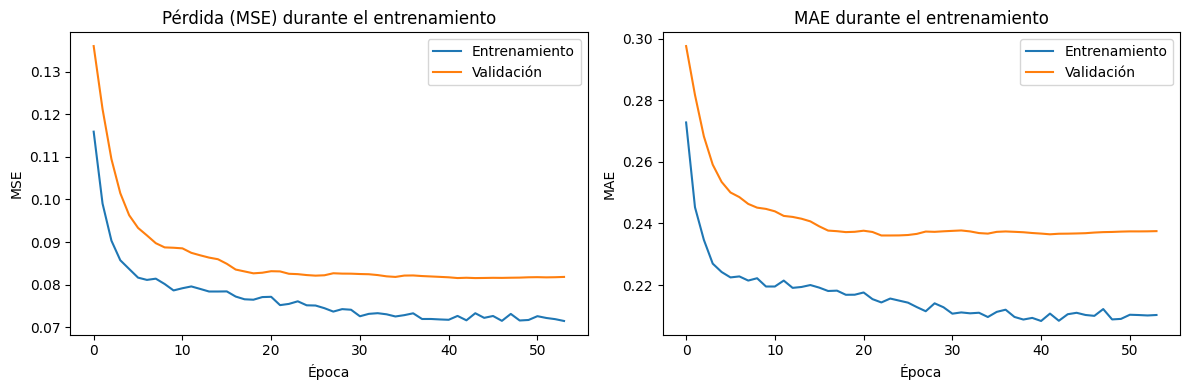

In [155]:
# ============================================
# 7. VISUALIZACIÓN DEL ENTRENAMIENTO (opcional)
# ============================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia.history['loss'], label='Entrenamiento')
plt.plot(historia.history['val_loss'], label='Validación')
plt.title('Pérdida (MSE) durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historia.history['mae'], label='Entrenamiento')
plt.plot(historia.history['val_mae'], label='Validación')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png')
plt.show()

In [156]:
# Guardar modelo y escaladores
modelo.save('lstm_model.keras')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_Y, 'scaler_Y.pkl')

print("Modelo y escaladores guardados correctamente")

Modelo y escaladores guardados correctamente
